<h1 style="color: darkblue; text-align: center;">
 Project: Website Traffic Data Analysis
</h1>

<p style="color: gray; font-size: 16px; text-align: center;">
explore and analyze website visit data using pandas, seaborn, and matplotlib.
</p>

Shape of the dataset: (10, 6)

Data types:
 VisitID                     int64
Date               datetime64[ns]
UserType                   object
Device                     object
SessionDuration             int64
PagesVisited                int64
dtype: object

Summary statistics:
         VisitID                 Date  SessionDuration  PagesVisited
count  10.00000                   10        10.000000     10.000000
mean    5.50000  2023-05-23 00:00:00       247.000000      4.400000
min     1.00000  2023-01-07 00:00:00       120.000000      3.000000
25%     3.25000  2023-03-14 18:00:00       195.000000      3.250000
50%     5.50000  2023-05-22 12:00:00       230.000000      4.000000
75%     7.75000  2023-07-30 06:00:00       290.000000      5.000000
max    10.00000  2023-10-07 00:00:00       400.000000      7.000000
std     3.02765                  NaN        83.672643      1.349897


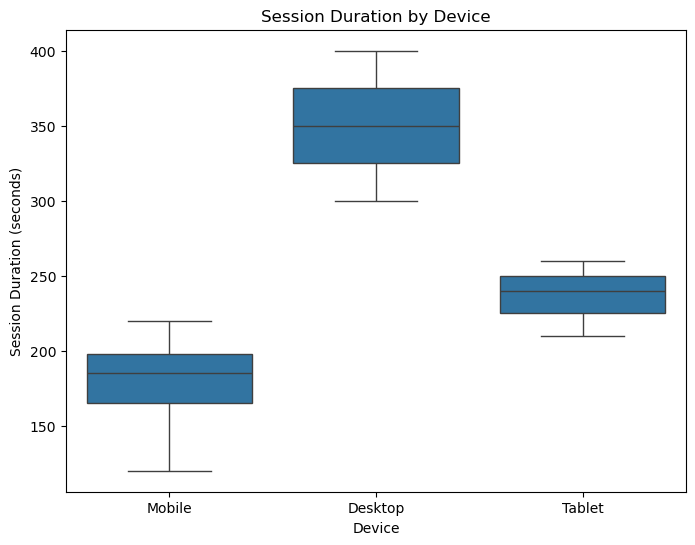

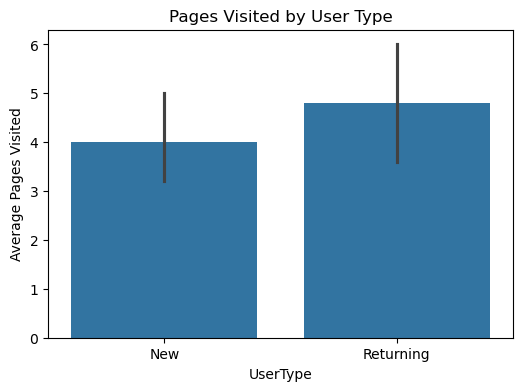

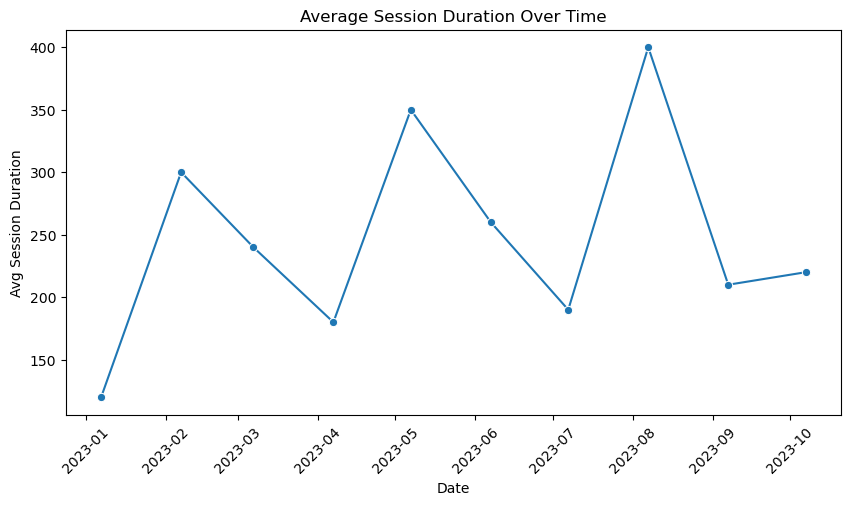

In [4]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
data = pd.read_csv("web_traffic_data.csv")  
data['Date'] = pd.to_datetime(data['Date'])
data.head()
print("Shape of the dataset:", data.shape)
print("\nData types:\n", data.dtypes)
print("\nSummary statistics:\n", data.describe())
plt.figure(figsize=(8,6))
sns.boxplot(x='Device', y='SessionDuration', data=data)
plt.title('Session Duration by Device')
plt.ylabel('Session Duration (seconds)')
plt.show()
plt.figure(figsize=(6,4))
sns.barplot(x='UserType', y='PagesVisited', data=data)
plt.title('Pages Visited by User Type')
plt.ylabel('Average Pages Visited')
plt.show()
daily_avg = data.groupby('Date')['SessionDuration'].mean().reset_index()

plt.figure(figsize=(10,5))
sns.lineplot(x='Date', y='SessionDuration', data=daily_avg, marker='o')
plt.title('Average Session Duration Over Time')
plt.ylabel('Avg Session Duration')
plt.xlabel('Date')
plt.xticks(rotation=45)
plt.show()


<h1 style="color: Orange; text-align: center;">
 Project: Ecommerce Sales Analysis
</h1>



<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100 entries, 0 to 99
Data columns (total 9 columns):
 #   Column           Non-Null Count  Dtype         
---  ------           --------------  -----         
 0   OrderID          100 non-null    int64         
 1   CustomerID       100 non-null    int64         
 2   OrderDate        45 non-null     datetime64[ns]
 3   Category         100 non-null    object        
 4   OrderValue       100 non-null    float64       
 5   DiscountApplied  100 non-null    int64         
 6   PaymentMethod    100 non-null    object        
 7   Revenue          100 non-null    float64       
 8   Month            45 non-null     period[M]     
dtypes: datetime64[ns](1), float64(2), int64(3), object(2), period[M](1)
memory usage: 7.2+ KB
None
           OrderID  CustomerID            OrderDate  OrderValue  \
count   100.000000  100.000000                   45  100.000000   
mean   1050.500000   10.010000  2024-06-08 13:52:00  101.712700   
min    1001.0

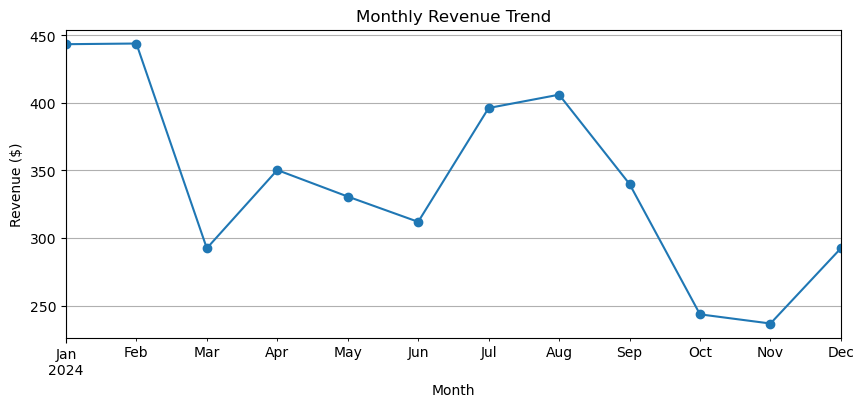

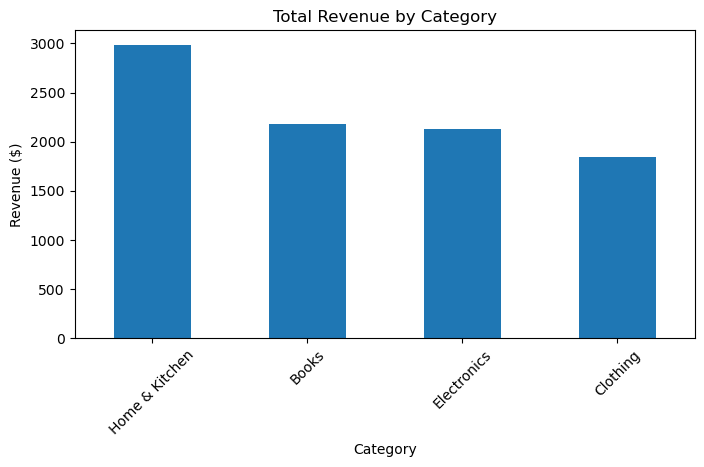

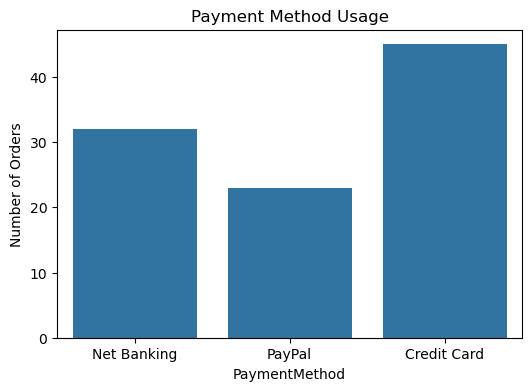

In [5]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# 2a. Load CSV
df = pd.read_csv('ecommerce_orders_csv.csv')

# 2b. Parse dates and extract month
df['OrderDate'] = pd.to_datetime(df['OrderDate'], errors='coerce')
df['Month']     = df['OrderDate'].dt.to_period('M')
# 3a. Quick info
print(df.info())

# 3b. Summary stats
print(df.describe())

# 3c. Check for nulls
print(df.isna().sum())
# 4a. Aggregate monthly revenue
monthly_revenue = df.groupby('Month')['Revenue'].sum()

# 4b. Plot trend
plt.figure(figsize=(10,4))
monthly_revenue.plot(marker='o')
plt.title('Monthly Revenue Trend')
plt.ylabel('Revenue ($)')
plt.xlabel('Month')
plt.grid(True)
plt.show()
# 5a. Sum revenue per category
cat_rev = df.groupby('Category')['Revenue'].sum().sort_values(ascending=False)

# 5b. Bar chart
plt.figure(figsize=(8,4))
cat_rev.plot(kind='bar')
plt.title('Total Revenue by Category')
plt.ylabel('Revenue ($)')
plt.xticks(rotation=45)
plt.show()
plt.figure(figsize=(6,4))
sns.countplot(x='PaymentMethod', data=df)
plt.title('Payment Method Usage')
plt.ylabel('Number of Orders')
plt.show()
